<a href="https://colab.research.google.com/github/aman-kannaujiya/Communication_engineering_project_OFDM/blob/main/rewardfunctionimprove2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

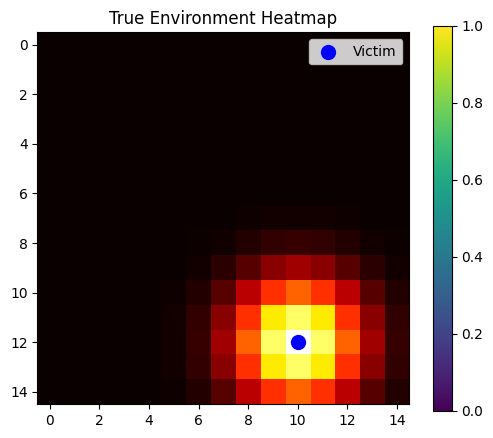

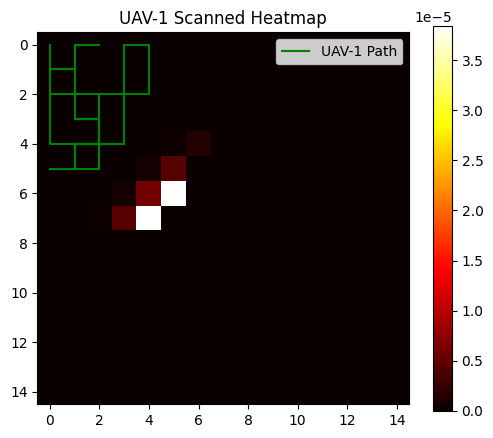

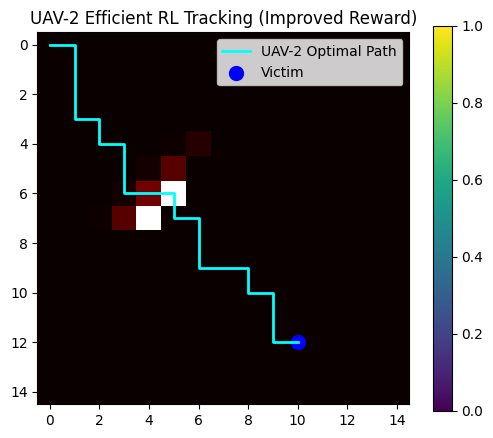

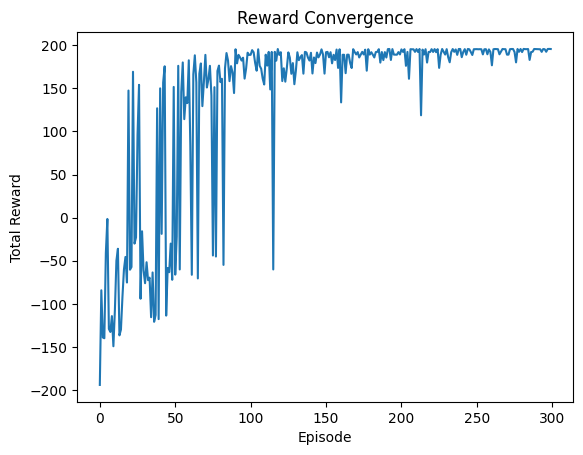

Simulation Completed Successfully 🚀


In [1]:
# part first more improve version of the reward convergence
import numpy as np
import matplotlib.pyplot as plt
import random

# ======================================
# PARAMETERS
# ======================================

GRID_SIZE = 15
SCAN_RADIUS = 2
EPISODES = 300
MAX_STEPS = 100

victim_pos = (12, 10)

# RL parameters
learning_rate = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

actions = [(1,0),(-1,0),(0,1),(0,-1)]

# ======================================
# TRUE HEATMAP (UNCHANGED)
# ======================================

def generate_heatmap():
    heat = np.zeros((GRID_SIZE, GRID_SIZE))
    for x in range(GRID_SIZE):
        for y in range(GRID_SIZE):
            dist_sq = (x - victim_pos[0])**2 + (y - victim_pos[1])**2
            heat[x, y] = np.exp(-dist_sq / 6)
    return heat

true_heatmap = generate_heatmap()

plt.figure(figsize=(6,5))
plt.imshow(true_heatmap, cmap='hot')
plt.scatter(victim_pos[1], victim_pos[0], c='blue', s=100, label='Victim')
plt.title("True Environment Heatmap")
plt.colorbar()
plt.legend()
plt.show()

# ======================================
# UAV-1 SCANNING (UNCHANGED)
# ======================================

def uav1_scanning():
    estimated = np.zeros((GRID_SIZE, GRID_SIZE))
    pos = (0,0)
    path = [pos]

    for step in range(60):
        x,y = pos

        for dx in range(-SCAN_RADIUS, SCAN_RADIUS+1):
            for dy in range(-SCAN_RADIUS, SCAN_RADIUS+1):
                nx, ny = x+dx, y+dy
                if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
                    estimated[nx, ny] = true_heatmap[nx, ny]

        move = random.choice(actions)
        pos = (
            max(0,min(GRID_SIZE-1,pos[0]+move[0])),
            max(0,min(GRID_SIZE-1,pos[1]+move[1]))
        )
        path.append(pos)

    return estimated, path

estimated_heatmap, uav1_path = uav1_scanning()

plt.figure(figsize=(6,5))
plt.imshow(estimated_heatmap, cmap='hot')
xs, ys = zip(*uav1_path)
plt.plot(ys, xs, color='green', label='UAV-1 Path')
plt.title("UAV-1 Scanned Heatmap")
plt.legend()
plt.colorbar()
plt.show()

# ======================================
# UAV-2 RL TRAINING (REWARD IMPROVED)
# ======================================

Q = np.zeros((GRID_SIZE, GRID_SIZE, len(actions)))
reward_history = []

for ep in range(EPISODES):

    state = (0,0)
    total_reward = 0
    visit_count = np.zeros((GRID_SIZE, GRID_SIZE))

    for step in range(MAX_STEPS):

        # Epsilon-Greedy
        if np.random.rand() < epsilon:
            action_idx = random.randint(0, len(actions)-1)
        else:
            action_idx = np.argmax(Q[state[0], state[1]])

        move = actions[action_idx]

        next_state = (
            max(0,min(GRID_SIZE-1,state[0]+move[0])),
            max(0,min(GRID_SIZE-1,state[1]+move[1]))
        )

        visit_count[next_state] += 1

        # =================================
        # 🔥 IMPROVED REWARD CALCULATION
        # =================================

        # 1️⃣ Absolute Heat Reward
        heat_abs = estimated_heatmap[next_state] * 2

        # 2️⃣ Heat Gradient Reward
        heat_grad = (estimated_heatmap[next_state] -
                     estimated_heatmap[state]) * 6

        # 3️⃣ Distance Improvement Reward
        old_dist = np.sqrt((state[0]-victim_pos[0])**2 +
                           (state[1]-victim_pos[1])**2)
        new_dist = np.sqrt((next_state[0]-victim_pos[0])**2 +
                           (next_state[1]-victim_pos[1])**2)

        distance_reward = (old_dist - new_dist) * 3

        # 4️⃣ Step Penalty
        step_penalty = -0.05

        # 5️⃣ Loop Penalty
        loop_penalty = -3 if visit_count[next_state] > 2 else 0

        reward = heat_abs + heat_grad + distance_reward + step_penalty + loop_penalty

        # 6️⃣ Strong Terminal Reward
        if next_state == victim_pos:
            reward += 150

        # =================================
        # Q-Learning Update
        # =================================

        Q[state[0], state[1], action_idx] += learning_rate * (
            reward +
            gamma * np.max(Q[next_state[0], next_state[1]]) -
            Q[state[0], state[1], action_idx]
        )

        state = next_state
        total_reward += reward

        if state == victim_pos:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    reward_history.append(total_reward)

# ======================================
# EXTRACT OPTIMAL PATH
# ======================================

state = (0,0)
tracking_path = [state]

for _ in range(60):
    action_idx = np.argmax(Q[state[0], state[1]])
    move = actions[action_idx]
    state = (
        max(0,min(GRID_SIZE-1,state[0]+move[0])),
        max(0,min(GRID_SIZE-1,state[1]+move[1]))
    )
    tracking_path.append(state)

    if state == victim_pos:
        break

plt.figure(figsize=(6,5))
plt.imshow(estimated_heatmap, cmap='hot')
xs, ys = zip(*tracking_path)
plt.plot(ys, xs, color='cyan', linewidth=2, label='UAV-2 Optimal Path')
plt.scatter(victim_pos[1], victim_pos[0], c='blue', s=100, label='Victim')
plt.title("UAV-2 Efficient RL Tracking (Improved Reward)")
plt.legend()
plt.colorbar()
plt.show()

# ======================================
# REWARD CONVERGENCE GRAPH
# ======================================

plt.figure()
plt.plot(reward_history)
plt.title("Reward Convergence")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

print("Simulation Completed Successfully 🚀")
